'\n# -----------------------------------------------------------\n# 6. Visualisation 3D : nuage de points des fortes valeurs\n# -----------------------------------------------------------\n\nthreshold = 0.1 * overlap.max()  # seuil à ajuster\nmask = overlap > threshold\n\nX_sel = X[mask]\nY_sel = Y[mask]\nZ_sel = Z[mask]\n\nfig = plt.figure()\nax = fig.add_subplot(111, projection=\'3d\')\nax.scatter(\n    X_sel / 1000.0,\n    Y_sel / 1000.0,\n    Z_sel / 1000.0,\n    s=5, alpha=0.3\n)\nax.set_xlabel("x (km)")\nax.set_ylabel("y (km)")\nax.set_zlabel("z (km)")\nax.set_title("Zone de fort recouvrement (nuage de points)")\nplt.tight_layout()\n\nplt.show()'

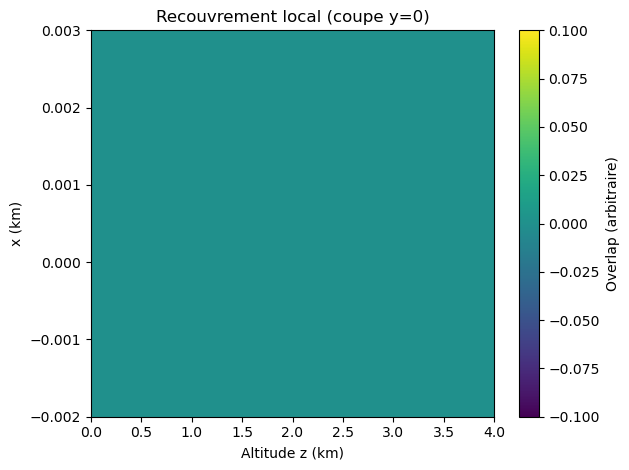

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # nécessaire pour les plots 3D

# -----------------------------------------------------------
# 1. Paramètres physiques / géométriques
# -----------------------------------------------------------

c = 3e8  # vitesse de la lumière (m/s)

# Positions des instruments (au sol)
r_B = np.array([0.0, 0.0, 0.0])     # bolomètre
L = 1.0                           # séparation horizontale (m)
r_L = np.array([L, 0.0, 0.0])       # lidar

# -----------------------------
# ORIENTATION DU BOLOMÈTRE
# -----------------------------
# Angles en degrés
el_bolo_deg = 45.0   # élévation (90° = zénith)
az_bolo_deg = 0.0    # azimut (0° = +x, 90° = +y)

el_bolo = np.deg2rad(el_bolo_deg)
az_bolo = np.deg2rad(az_bolo_deg)

e_B = np.array([
    np.cos(el_bolo) * np.cos(az_bolo),
    np.cos(el_bolo) * np.sin(az_bolo),
    np.sin(el_bolo),
])

# -----------------------------
# ORIENTATION DU LIDAR
# -----------------------------
# Exemple : élévation 60°, azimut 180° (vers le bolomètre)
el_lidar_deg = 45.0
az_lidar_deg = 0.0

el_lidar = np.deg2rad(el_lidar_deg)
az_lidar = np.deg2rad(az_lidar_deg)

e_L = np.array([
    np.cos(el_lidar) * np.cos(az_lidar),
    np.cos(el_lidar) * np.sin(az_lidar),
    np.sin(el_lidar),
])

# Normalisation par sécurité
e_B = e_B / np.linalg.norm(e_B)
e_L = e_L / np.linalg.norm(e_L)

# -----------------------------
# FRÉQUENCES et ANGLES D’OUVERTURE
# -----------------------------
# Fréquences (Hz) – à adapter
freq_B = 150e9      # ex : 150 GHz pour le bolomètre
freq_L = 850e12     # ex : 852 THz (355 nm) pour le lidar

lambda_B = c / freq_B
lambda_L = c / freq_L

# Angles d’ouverture TOTAUX (FWHM ou 1/e^2 suivant ton choix) en degrés
# Ici on suppose que c’est l’angle total, on en déduit le demi-angle
#full_angle_B_deg = 1.0*   # exemple : 1° d’ouverture totale pour le bolo
#full_angle_L_deg = 0.2   # exemple : 0.2° pour le lidar

#theta_B = np.deg2rad(full_angle_B_deg / 2.0)  # demi-angle en radians
#theta_L = np.deg2rad(full_angle_L_deg / 2.0)
theta_B = 0.6e-3 #0.3 mrad
theta_L=2e-3 #2mrad

# Waists à l’origine à partir de la divergence gaussienne
# relation approx : theta ≈ lambda / (pi * w0)
w0_B = lambda_B / (np.pi * theta_B)
w0_L = lambda_L / (np.pi * theta_L)

# Longueurs de Rayleigh
zR_B = np.pi * w0_B**2 / lambda_B
zR_L = np.pi * w0_L**2 / lambda_L

# Intensités de référence (échelle relative)
I0_B = 1.0
I0_L = 1.0


# -----------------------------------------------------------
# 2. Fonction utilitaire pour faisceau gaussien 3D
# -----------------------------------------------------------

def beam_geometry(r, r0, e_hat, w0, zR, I0):
    """
    Calcule l'intensité d'un faisceau gaussien 3D au point r.

    r   : (..., 3) points dans l'espace
    r0  : (3,) position de l'origine du faisceau
    e_hat : (3,) vecteur unitaire direction de propagation
    w0  : waist à l'origine
    zR  : longueur de Rayleigh
    I0  : amplitude d'intensité

    Retourne :
        I : intensité au point r (même shape que r[...,0])
    """
    # vecteur depuis l'origine du faisceau
    dr = r - r0

    # coordonnée le long de l'axe (projection sur e_hat)
    s = np.dot(dr, e_hat)

    # norme au carré de dr
    dr2 = np.sum(dr**2, axis=-1)

    # distance transverse au carré à l'axe : |dr|^2 - s^2
    rho2 = dr2 - s**2

    # waist en fonction de s
    w_s = w0 * np.sqrt(1.0 + (s / zR)**2)

    # intensité gaussienne transverse (on ignore la phase)
    I = I0 * np.exp(-2.0 * rho2 / (w_s**2))

    # Optionnel : annuler l'intensité pour s < 0 (avant l'origine)
    I = np.where(s >= 0.0, I, 0.0)

    return I


# -----------------------------------------------------------
# 3. Grille de calcul dans l'espace
# -----------------------------------------------------------

# Domaine en x, y, z (en m)
x_min, x_max, Nx = -2.0, L + 2.0, 120
y_min, y_max, Ny = -2.0, 2.0, 80
z_min, z_max, Nz = 0.0, 4000.0, 120

x = np.linspace(x_min, x_max, Nx)
y = np.linspace(y_min, y_max, Ny)
z = np.linspace(z_min, z_max, Nz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')  # shape (Nx, Ny, Nz)

# Empilement pour obtenir un array (..., 3)
R = np.stack([X, Y, Z], axis=-1)  # shape (Nx, Ny, Nz, 3)

# -----------------------------------------------------------
# 4. Intensités locales et recouvrement
# -----------------------------------------------------------

I_B = beam_geometry(R, r_B, e_B, w0_B, zR_B, I0_B)
I_L = beam_geometry(R, r_L, e_L, w0_L, zR_L, I0_L)

overlap = I_B * I_L  # recouvrement local


# -----------------------------------------------------------
# 5. Visualisation 2D : coupe dans le plan y = 0 (x-z)
# -----------------------------------------------------------

# On trouve l'indice de y le plus proche de 0
iy0 = np.argmin(np.abs(y))

overlap_xz = overlap[:, iy0, :]  # shape (Nx, Nz)

plt.figure()
extent = [z_min / 1000.0, z_max / 1000.0, x_min / 1000.0, x_max / 1000.0]  # en km
plt.imshow(
    overlap_xz,
    origin='lower',
    aspect='auto',
    extent=extent
)
plt.xlabel("Altitude z (km)")
plt.ylabel("x (km)")
plt.title("Recouvrement local (coupe y=0)")
plt.colorbar(label="Overlap (arbitraire)")
plt.tight_layout()

"""
# -----------------------------------------------------------
# 6. Visualisation 3D : nuage de points des fortes valeurs
# -----------------------------------------------------------

threshold = 0.1 * overlap.max()  # seuil à ajuster
mask = overlap > threshold

X_sel = X[mask]
Y_sel = Y[mask]
Z_sel = Z[mask]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X_sel / 1000.0,
    Y_sel / 1000.0,
    Z_sel / 1000.0,
    s=5, alpha=0.3
)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_zlabel("z (km)")
ax.set_title("Zone de fort recouvrement (nuage de points)")
plt.tight_layout()

plt.show()"""


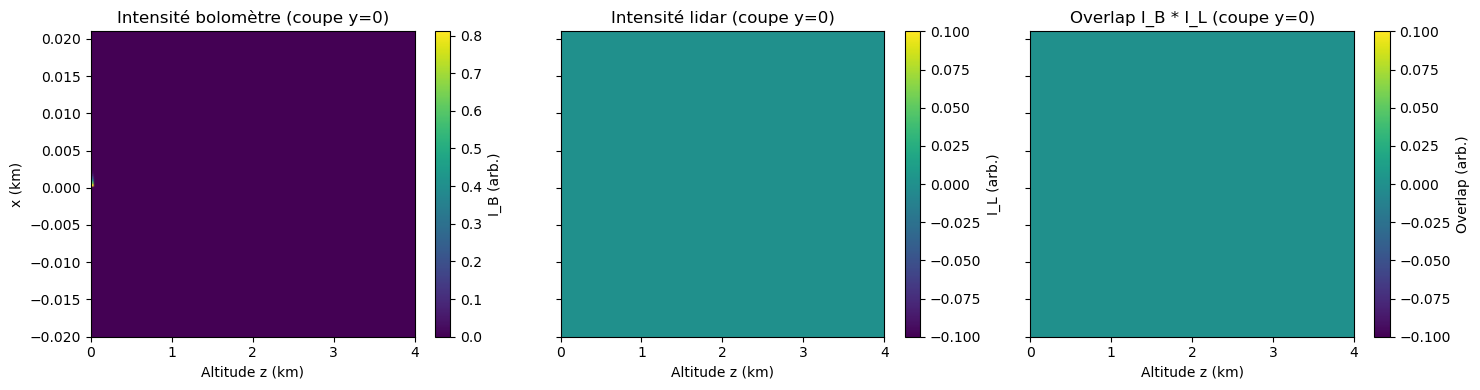

el_lidar_deg = 45.01350792834139
az_lidar_deg = 0.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # nécessaire pour les plots 3D

# -----------------------------------------------------------
# 1. Paramètres physiques / géométriques
# -----------------------------------------------------------

c = 3e8  # vitesse de la lumière (m/s)

# Positions des instruments (au sol)
r_B = np.array([0.0, 0.0, 0.0])   # bolomètre
L = 1.0                           # séparation horizontale (m)
r_L = np.array([L, 0.0, 0.0])     # lidar

# -----------------------------
# ORIENTATION DU BOLOMÈTRE
# -----------------------------
# Angles en degrés
el_bolo_deg = 45.0   # élévation (90° = zénith)
az_bolo_deg = 0.0    # azimut (0° = +x, 90° = +y)

el_bolo = np.deg2rad(el_bolo_deg)
az_bolo = np.deg2rad(az_bolo_deg)

# vecteur unitaire de visée du bolo
e_B = np.array([
    np.cos(el_bolo) * np.cos(az_bolo),
    np.cos(el_bolo) * np.sin(az_bolo),
    np.sin(el_bolo),
])
e_B = e_B / np.linalg.norm(e_B)

# -----------------------------
# POINT CIBLE COMMUN DANS L'ESPACE
# -----------------------------
# -> C'est ici que tu choisis "le point qu'ils regardent"
# Option simple : distance le long du faisceau du bolomètre
s_target = 3000.0  # distance en m le long du faisceau du bolo (à ajuster)

V = r_B + s_target * e_B  # point dans l'atmosphère

# -----------------------------
# ORIENTATION DU LIDAR VERS CE POINT
# -----------------------------
e_L = V - r_L
e_L = e_L / np.linalg.norm(e_L)

# -----------------------------
# FRÉQUENCES et ANGLES D’OUVERTURE
# -----------------------------
# Fréquences (Hz) – à adapter
freq_B = 150e9      # ex : 150 GHz pour le bolomètre
freq_L = 850e12     # ex : 852 THz (355 nm) pour le lidar

lambda_B = c / freq_B
lambda_L = c / freq_L

# Demi-angles d'ouverture (radians)
theta_B = 0.6e-3    # ~0.6 mrad
theta_L = 2e-3      # 2 mrad

# Waists à l’origine à partir de la divergence gaussienne
# relation approx : theta ≈ lambda / (pi * w0)
w0_B = lambda_B / (np.pi * theta_B)
w0_L = lambda_L / (np.pi * theta_L)

# Longueurs de Rayleigh
zR_B = np.pi * w0_B**2 / lambda_B
zR_L = np.pi * w0_L**2 / lambda_L

# Intensités de référence (échelle relative)
I0_B = 1.0
I0_L = 1.0


# -----------------------------------------------------------
# 2. Fonction utilitaire pour faisceau gaussien 3D
# -----------------------------------------------------------

def beam_geometry(r, r0, e_hat, w0, zR, I0):
    """
    Calcule l'intensité d'un faisceau gaussien 3D au point r.

    r   : (..., 3) points dans l'espace
    r0  : (3,) position de l'origine du faisceau
    e_hat : (3,) vecteur unitaire direction de propagation
    w0  : waist à l'origine
    zR  : longueur de Rayleigh
    I0  : amplitude d'intensité

    Retourne :
        I : intensité au point r (même shape que r[...,0])
    """
    dr = r - r0              # vecteur depuis l'origine du faisceau
    s = np.dot(dr, e_hat)    # coordonnée le long de l'axe
    dr2 = np.sum(dr**2, axis=-1)
    rho2 = dr2 - s**2        # distance transverse au carré à l'axe

    w_s = w0 * np.sqrt(1.0 + (s / zR)**2)  # waist en fonction de s

    I = I0 * np.exp(-2.0 * rho2 / (w_s**2))   # profile gaussien transverse
    I = np.where(s >= 0.0, I, 0.0)            # option : pas de faisceau pour s<0

    return I


# -----------------------------------------------------------
# 3. Grille de calcul dans l'espace
# -----------------------------------------------------------

# Domaine en x, y, z (en m)
x_min, x_max, Nx = -20.0, L + 20.0, 120
y_min, y_max, Ny = -20.0, 20.0, 80
z_min, z_max, Nz = 0.0, 4000.0, 120

x = np.linspace(x_min, x_max, Nx)
y = np.linspace(y_min, y_max, Ny)
z = np.linspace(z_min, z_max, Nz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')  # shape (Nx, Ny, Nz)
R = np.stack([X, Y, Z], axis=-1)              # shape (Nx, Ny, Nz, 3)

# -----------------------------------------------------------
# 4. Intensités locales et recouvrement
# -----------------------------------------------------------

I_B = beam_geometry(R, r_B, e_B, w0_B, zR_B, I0_B)
I_L = beam_geometry(R, r_L, e_L, w0_L, zR_L, I0_L)

overlap = I_B * I_L  # recouvrement local


# -----------------------------------------------------------
# 5. Visualisation 2D : coupes dans le plan y = 0 (x-z)
# -----------------------------------------------------------

# indice de y le plus proche de 0
iy0 = np.argmin(np.abs(y))

I_B_xz      = I_B[:, iy0, :]       # bolo
I_L_xz      = I_L[:, iy0, :]       # lidar
overlap_xz  = overlap[:, iy0, :]   # recouvrement

extent = [z_min / 1000.0, z_max / 1000.0, x_min / 1000.0, x_max / 1000.0]  # en km

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

im0 = axes[0].imshow(
    I_B_xz,
    origin='lower',
    aspect='auto',
    extent=extent
)
axes[0].set_title("Intensité bolomètre (coupe y=0)")
axes[0].set_xlabel("Altitude z (km)")
axes[0].set_ylabel("x (km)")
plt.colorbar(im0, ax=axes[0], label="I_B (arb.)")

im1 = axes[1].imshow(
    I_L_xz,
    origin='lower',
    aspect='auto',
    extent=extent
)
axes[1].set_title("Intensité lidar (coupe y=0)")
axes[1].set_xlabel("Altitude z (km)")
plt.colorbar(im1, ax=axes[1], label="I_L (arb.)")

im2 = axes[2].imshow(
    overlap_xz,
    origin='lower',
    aspect='auto',
    extent=extent
)
axes[2].set_title("Overlap I_B * I_L (coupe y=0)")
axes[2].set_xlabel("Altitude z (km)")
plt.colorbar(im2, ax=axes[2], label="Overlap (arb.)")

plt.tight_layout()
plt.show()




# À partir de e_L, calcul des angles équivalents du lidar
el_lidar = np.arcsin(e_L[2])  # composante z
az_lidar = np.arctan2(e_L[1], e_L[0])

el_lidar_deg = np.rad2deg(el_lidar)
az_lidar_deg = np.rad2deg(az_lidar)
print("el_lidar_deg =", el_lidar_deg)
print("az_lidar_deg =", az_lidar_deg)


Point cible V = [3.061617e-14 0.000000e+00 5.000000e+02]
el_lidar_deg = 89.8854085937637
az_lidar_deg = 180.0


max I_B = 0.5896341578882662 max I_L = 0.6234424448835777 max overlap = 0.36760296098073014


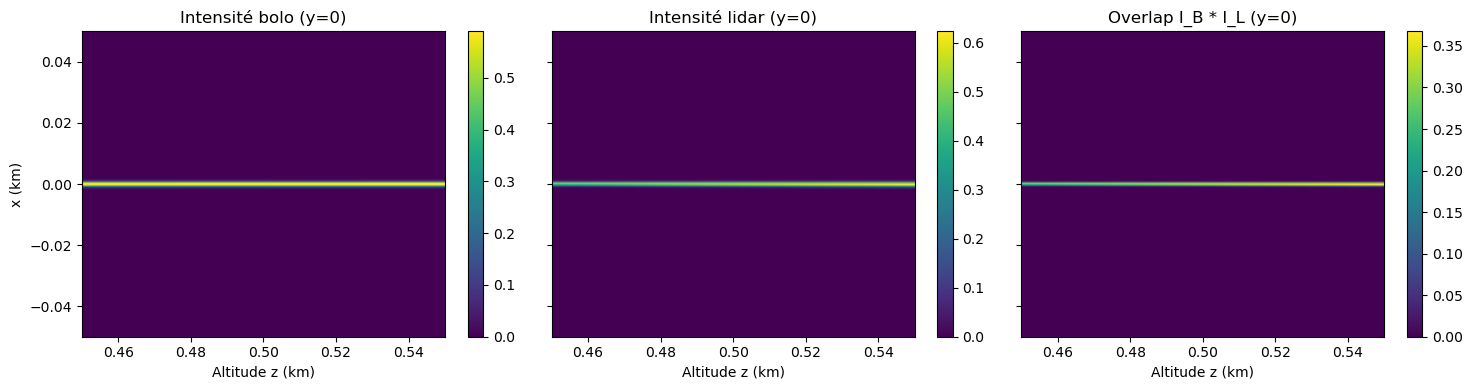

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------------------------------------
# 1. Paramètres physiques / géométriques
# -----------------------------------------------------------

c = 3e8  # vitesse de la lumière (m/s)

# Positions des instruments (au sol)
r_B = np.array([0.0, 0.0, 0.0])   # bolomètre
L = 1.0                           # séparation horizontale (m)
r_L = np.array([L, 0.0, 0.0])     # lidar

# -----------------------------
# ORIENTATION DU BOLOMÈTRE
# -----------------------------
el_bolo_deg = 90.0   # élévation bolo
az_bolo_deg = 0.0    # azimut bolo

el_bolo = np.deg2rad(el_bolo_deg)
az_bolo = np.deg2rad(az_bolo_deg)

e_B = np.array([
    np.cos(el_bolo) * np.cos(az_bolo),
    np.cos(el_bolo) * np.sin(az_bolo),
    np.sin(el_bolo),
])
e_B /= np.linalg.norm(e_B)

# -----------------------------
# POINT CIBLE COMMUN DANS L'ESPACE
# -----------------------------
# Ici tu CHOISIS le point que les deux regardent.
# Exemple : 500 m le long du faisceau du bolo
s_target = 500.0  # m
V = r_B + s_target * e_B    # point cible

print("Point cible V =", V)

# -----------------------------
# ORIENTATION DU LIDAR VERS CE POINT
# -----------------------------
e_L = V - r_L
e_L /= np.linalg.norm(e_L)

# (pour info, on peut récupérer les angles équivalents du lidar)
el_lidar = np.arcsin(e_L[2])
az_lidar = np.arctan2(e_L[1], e_L[0])
print("el_lidar_deg =", np.rad2deg(el_lidar))
print("az_lidar_deg =", np.rad2deg(az_lidar))

# -----------------------------
# FRÉQUENCES et ANGLES D’OUVERTURE
# -----------------------------
freq_B = 150e9      # Hz
freq_L = 850e12     # Hz

lambda_B = c / freq_B
lambda_L = c / freq_L

theta_B = 0.6e-3    # rad
theta_L = 2e-3      # rad

w0_B = lambda_B / (np.pi * theta_B)
w0_L = lambda_L / (np.pi * theta_L)

zR_B = np.pi * w0_B**2 / lambda_B
zR_L = np.pi * w0_L**2 / lambda_L

I0_B = 1.0
I0_L = 1.0

# -----------------------------------------------------------
# 2. Faisceau gaussien 3D
# -----------------------------------------------------------

def beam_geometry(r, r0, e_hat, w0, zR, I0):
    dr = r - r0
    s = np.dot(dr, e_hat)
    dr2 = np.sum(dr**2, axis=-1)
    rho2 = dr2 - s**2
    w_s = w0 * np.sqrt(1.0 + (s / zR)**2)
    I = I0 * np.exp(-2.0 * rho2 / (w_s**2))
    I = np.where(s >= 0.0, I, 0.0)
    return I

# -----------------------------------------------------------
# 3. Grille de calcul centrée sur le volume V
# -----------------------------------------------------------

# On se fait une fenêtre autour de V pour bien voir l'overlap
margin_x = 50.0   # m autour de V en x
margin_z = 50.0   # m autour de V en z

x_min, x_max = V[0] - margin_x, V[0] + margin_x
z_min, z_max = max(0.0, V[2] - margin_z), V[2] + margin_z

# En y, on peut rester autour de 0 (plan contenant les deux axes)
y_min, y_max = -20.0, 20.0

Nx, Ny, Nz = 200, 40, 200

x = np.linspace(x_min, x_max, Nx)
y = np.linspace(y_min, y_max, Ny)
z = np.linspace(z_min, z_max, Nz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
R = np.stack([X, Y, Z], axis=-1)

# -----------------------------------------------------------
# 4. Intensités et recouvrement
# -----------------------------------------------------------

I_B = beam_geometry(R, r_B, e_B, w0_B, zR_B, I0_B)
I_L = beam_geometry(R, r_L, e_L, w0_L, zR_L, I0_L)
overlap = I_B * I_L

print("max I_B =", I_B.max(), "max I_L =", I_L.max(), "max overlap =", overlap.max())

# -----------------------------------------------------------
# 5. Coupes 2D (plan y = 0)
# -----------------------------------------------------------

iy0 = np.argmin(np.abs(y))  # y ~ 0
I_B_xz = I_B[:, iy0, :]
I_L_xz = I_L[:, iy0, :]
overlap_xz = overlap[:, iy0, :]

extent = [z_min/1000.0, z_max/1000.0, x_min/1000.0, x_max/1000.0]  # km

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

im0 = axes[0].imshow(I_B_xz, origin='lower', aspect='auto', extent=extent)
axes[0].set_title("Intensité bolo (y=0)")
axes[0].set_xlabel("Altitude z (km)")
axes[0].set_ylabel("x (km)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(I_L_xz, origin='lower', aspect='auto', extent=extent)
axes[1].set_title("Intensité lidar (y=0)")
axes[1].set_xlabel("Altitude z (km)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(overlap_xz, origin='lower', aspect='auto', extent=extent)
axes[2].set_title("Overlap I_B * I_L (y=0)")
axes[2].set_xlabel("Altitude z (km)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


Point cible V = [353.55339059   0.         353.55339059]
el_lidar_deg = 45.081143168050865
az_lidar_deg = 0.0
max I_B = 0.9493301672066515 max I_L = 0.9957357322874689 max overlap = 0.4868833036533769


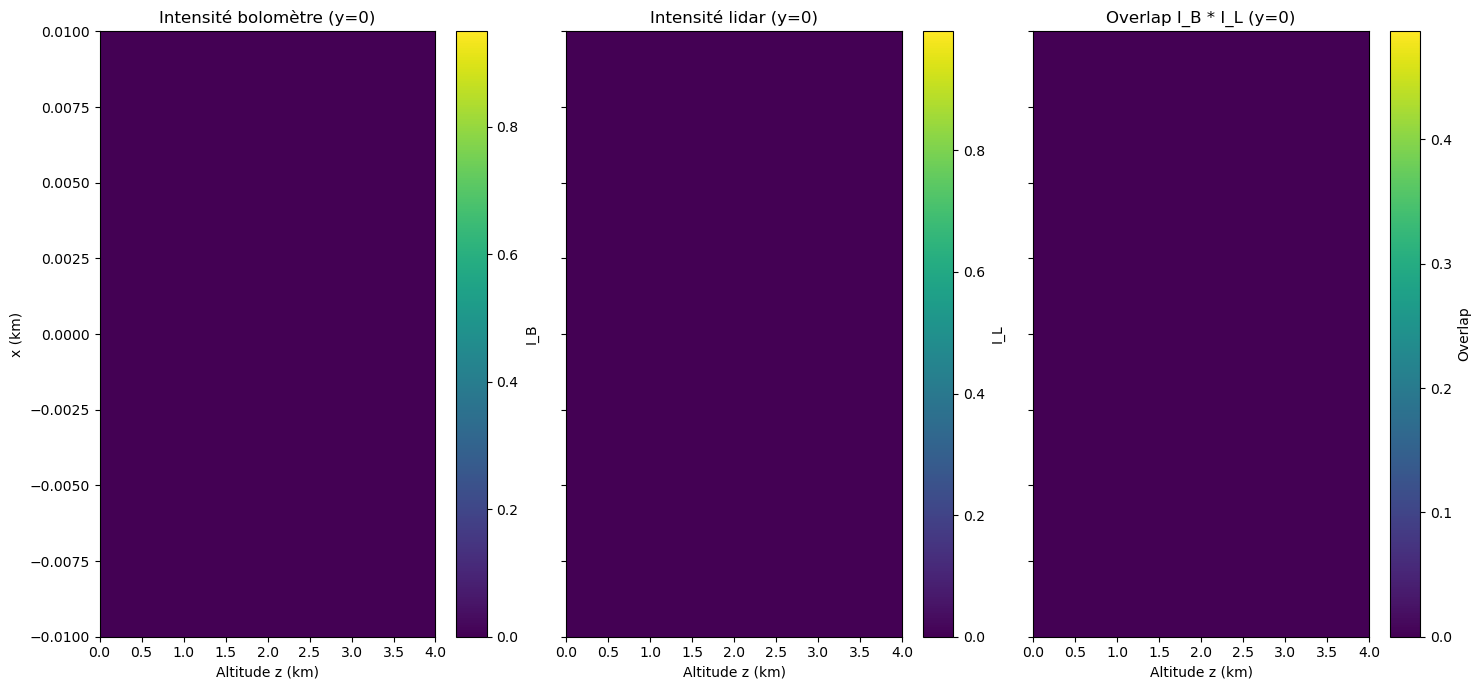

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------------------------------------
# 1. Paramètres physiques / géométriques
# -----------------------------------------------------------

c = 3e8  # vitesse de la lumière (m/s)

# Positions des instruments (au sol)
r_B = np.array([0.0, 0.0, 0.0])   # bolomètre
L = 1.0                           # séparation horizontale (m)
r_L = np.array([L, 0.0, 0.0])     # lidar

# -----------------------------
# ORIENTATION DU BOLOMÈTRE
# -----------------------------
el_bolo_deg = 45.0   # élévation bolo
az_bolo_deg = 0.0    # azimut bolo

el_bolo = np.deg2rad(el_bolo_deg)
az_bolo = np.deg2rad(az_bolo_deg)

e_B = np.array([
    np.cos(el_bolo) * np.cos(az_bolo),
    np.cos(el_bolo) * np.sin(az_bolo),
    np.sin(el_bolo),
])
e_B /= np.linalg.norm(e_B)

# -----------------------------
# POINT CIBLE COMMUN DANS L'ESPACE
# -----------------------------
# Ici tu CHOISIS le point que les deux regardent.
# Exemple : 500 m le long du faisceau du bolo
s_target = 500  # m
V = r_B + s_target * e_B    # point cible

print("Point cible V =", V)

# -----------------------------
# ORIENTATION DU LIDAR VERS CE POINT
# -----------------------------
e_L = V - r_L
e_L /= np.linalg.norm(e_L)

# (pour info, on peut récupérer les angles équivalents du lidar)
el_lidar = np.arcsin(e_L[2])
az_lidar = np.arctan2(e_L[1], e_L[0])
print("el_lidar_deg =", np.rad2deg(el_lidar))
print("az_lidar_deg =", np.rad2deg(az_lidar))

# -----------------------------
# FRÉQUENCES et ANGLES D’OUVERTURE
# -----------------------------
freq_B = 150e9      # Hz
freq_L = 850e12     # Hz

lambda_B = c / freq_B
lambda_L = c / freq_L

theta_B = 0.6e-3    # rad
theta_L = 2e-3      # rad

w0_B = lambda_B / (np.pi * theta_B)
w0_L = lambda_L / (np.pi * theta_L)

zR_B = np.pi * w0_B**2 / lambda_B
zR_L = np.pi * w0_L**2 / lambda_L

I0_B = 1.0
I0_L = 1.0

# -----------------------------------------------------------
# 2. Faisceau gaussien 3D
# -----------------------------------------------------------

def beam_geometry(r, r0, e_hat, w0, zR, I0):
    dr = r - r0
    s = np.dot(dr, e_hat)
    dr2 = np.sum(dr**2, axis=-1)
    rho2 = dr2 - s**2
    w_s = w0 * np.sqrt(1.0 + (s / zR)**2)
    I = I0 * np.exp(-2.0 * rho2 / (w_s**2))
    I = np.where(s >= 0.0, I, 0.0)
    return I

# -----------------------------------------------------------
# 3. Grille de calcul dans l'espace (suivant l'angle d'élévation)
# -----------------------------------------------------------

z_min, z_max = 0.0, 4000.0  # m
el_bolo = np.deg2rad(el_bolo_deg)

# position en x du faisceau du bolo à z_max
x_bolo_max = z_max / np.tan(el_bolo)

margin = 100.0  # m
x_min = min(0.0, L) - margin
x_max = max(x_bolo_max, L) + margin

y_min, y_max = -50.0, 50.0  # plan proche de y=0

Nx, Ny, Nz = 300, 100, 400   # résolution (à ajuster)

x = np.linspace(x_min, x_max, Nx)
y = np.linspace(y_min, y_max, Ny)
z = np.linspace(z_min, z_max, Nz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
R = np.stack([X, Y, Z], axis=-1)

# -----------------------------------------------------------
# 4. Intensités locales et recouvrement
# -----------------------------------------------------------

I_B = beam_geometry(R, r_B, e_B, w0_B, zR_B, I0_B)
I_L = beam_geometry(R, r_L, e_L, w0_L, zR_L, I0_L)
overlap = I_B * I_L

print("max I_B =", I_B.max(), "max I_L =", I_L.max(), "max overlap =", overlap.max())

# -----------------------------------------------------------
# 5. Visualisation 2D : coupes dans le plan y = 0 (x-z)
# -----------------------------------------------------------

iy0 = np.argmin(np.abs(y))  # y ~ 0

I_B_xz = I_B[:, iy0, :]
I_L_xz = I_L[:, iy0, :]
overlap_xz = overlap[:, iy0, :]

extent = [z_min/1000.0, z_max/1000.0, x_min/1000.0, x_max/1000.0]  # z en km, x en km

fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharex=True, sharey=True)

im0 = axes[0].imshow(I_B_xz, origin='lower', aspect='auto', extent=extent)
axes[0].set_title("Intensité bolomètre (y=0)")
axes[0].set_xlabel("Altitude z (km)")
axes[0].set_ylabel("x (km)")
plt.colorbar(im0, ax=axes[0], label="I_B")

im1 = axes[1].imshow(I_L_xz, origin='lower', aspect='auto', extent=extent)
axes[1].set_title("Intensité lidar (y=0)")
axes[1].set_xlabel("Altitude z (km)")
plt.colorbar(im1, ax=axes[1], label="I_L")

im2 = axes[2].imshow(overlap_xz, origin='lower', aspect='auto', extent=extent)
axes[2].set_title("Overlap I_B * I_L (y=0)")
axes[2].set_xlabel("Altitude z (km)")
plt.colorbar(im2, ax=axes[2], label="Overlap")
plt.ylim(-0.01, 0.01)
plt.tight_layout()
plt.show()


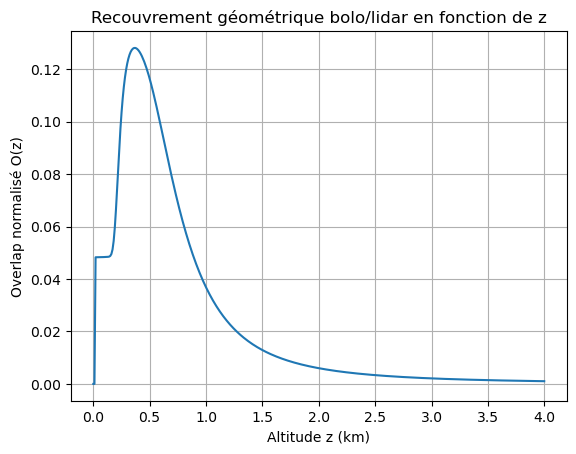

In [30]:
# On suppose que I_B, I_L, x, y, z existent déjà
dx = x[1] - x[0]
dy = y[1] - y[0]

O_z = []

for iz in range(len(z)):
    IB_plane = I_B[:, :, iz]
    IL_plane = I_L[:, :, iz]

    # Si tout est quasi nul dans le plan, on évite de normaliser par ~0
    if IB_plane.sum() <= 0 or IL_plane.sum() <= 0:
        O_z.append(0.0)
        continue

    fB = IB_plane / IB_plane.sum()
    fL = IL_plane / IL_plane.sum()

    # recouvrement normalisé dans ce plan
    overlap_plane = fB * fL
    O = overlap_plane.sum() * dx * dy   # intégrale ~ somme * dx * dy
    O_z.append(O)

O_z = np.array(O_z)

plt.figure()
plt.plot(z/1000.0, O_z)
plt.xlabel("Altitude z (km)")
plt.ylabel("Overlap normalisé O(z)")
plt.title("Recouvrement géométrique bolo/lidar en fonction de z")
plt.grid(True)
plt.show()


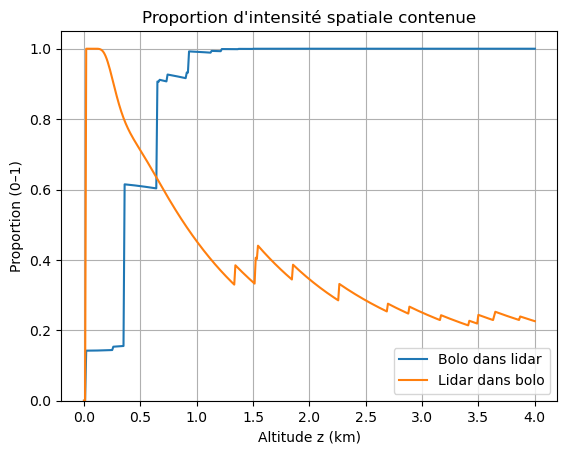

In [25]:
dx = x[1] - x[0]
dy = y[1] - y[0]

tau = 0.1   # seuil relatif (10% du max), à ajuster

P_B_in_L = []
P_L_in_B = []

for iz in range(len(z)):
    IB_plane = I_B[:, :, iz]
    IL_plane = I_L[:, :, iz]

    # Si quasi rien dans le plan, on évite les divisions débiles
    sum_IB = IB_plane.sum()
    sum_IL = IL_plane.sum()
    if sum_IB <= 0 or sum_IL <= 0:
        P_B_in_L.append(0.0)
        P_L_in_B.append(0.0)
        continue

    # Seuils
    thr_B = tau * IB_plane.max()
    thr_L = tau * IL_plane.max()

    mask_B = IB_plane > thr_B
    mask_L = IL_plane > thr_L

    # Fraction de bolo dans le lidar
    frac_B_in_L = IB_plane[mask_L].sum() / sum_IB
    # Fraction de lidar dans le bolo
    frac_L_in_B = IL_plane[mask_B].sum() / sum_IL

    P_B_in_L.append(frac_B_in_L)
    P_L_in_B.append(frac_L_in_B)

P_B_in_L = np.array(P_B_in_L)
P_L_in_B = np.array(P_L_in_B)

plt.figure()
plt.plot(z/1000.0, P_B_in_L, label="Bolo dans lidar")
plt.plot(z/1000.0, P_L_in_B, label="Lidar dans bolo")
plt.xlabel("Altitude z (km)")
plt.ylabel("Proportion (0–1)")
plt.title("Proportion d'intensité spatiale contenue")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()


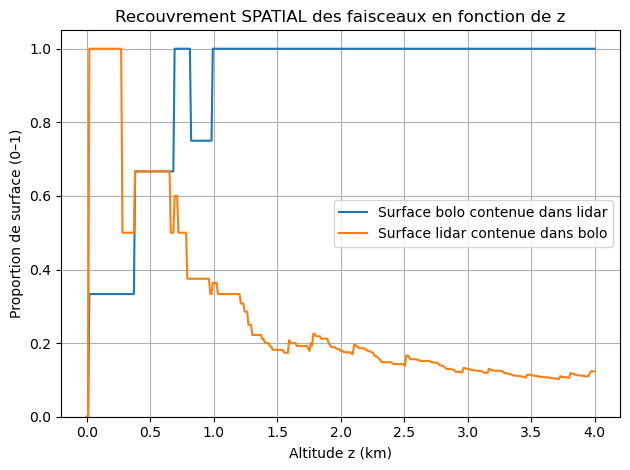

In [26]:
# -----------------------------------------------------------
# 6. Recouvrement SPATIAL (en aire) bolo <-> lidar
# -----------------------------------------------------------

dx = x[1] - x[0]
dy = y[1] - y[0]

tau = 0.135  # ~ e^{-2} : définit la "frontière" du faisceau (1/e^2)
# tu peux tester aussi tau = 0.5 (FWHM approx) ou autre

P_B_in_L_area = []  # fraction de surface du BOLO contenue dans le LIDAR
P_L_in_B_area = []  # fraction de surface du LIDAR contenue dans le BOLO

for iz in range(len(z)):
    IB_plane = I_B[:, :, iz]
    IL_plane = I_L[:, :, iz]

    # si le plan est vide pour l'un des deux, on met 0 par sécurité
    if IB_plane.max() <= 0 or IL_plane.max() <= 0:
        P_B_in_L_area.append(0.0)
        P_L_in_B_area.append(0.0)
        continue

    # seuils relatifs pour définir les "taches" spatiales
    thr_B = tau * IB_plane.max()
    thr_L = tau * IL_plane.max()

    mask_B = IB_plane > thr_B   # zone où le faisceau bolo est "présent"
    mask_L = IL_plane > thr_L   # zone où le faisceau lidar est "présent"

    # aires (en m²) – pas obligatoire pour les proportions, mais propre
    area_B      = mask_B.sum() * dx * dy
    area_L      = mask_L.sum() * dx * dy
    area_B_in_L = (mask_B & mask_L).sum() * dx * dy
    area_L_in_B = (mask_L & mask_B).sum() * dx * dy  # même intersection

    if area_B > 0:
        P_B_in_L_area.append(area_B_in_L / area_B)
    else:
        P_B_in_L_area.append(0.0)

    if area_L > 0:
        P_L_in_B_area.append(area_L_in_B / area_L)
    else:
        P_L_in_B_area.append(0.0)

P_B_in_L_area = np.array(P_B_in_L_area)
P_L_in_B_area = np.array(P_L_in_B_area)

# -----------------------------------------------------------
# 7. Plot des recouvrements spatiaux en fonction de l'altitude
# -----------------------------------------------------------

plt.figure()
plt.plot(z/1000.0, P_B_in_L_area, label="Surface bolo contenue dans lidar")
plt.plot(z/1000.0, P_L_in_B_area, label="Surface lidar contenue dans bolo")
plt.xlabel("Altitude z (km)")
plt.ylabel("Proportion de surface (0–1)")
plt.title("Recouvrement SPATIAL des faisceaux en fonction de z")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


le problème de ça c'est que ça ne prend pas en compte quand le bolo est entièrement dans celui du lidar et que ça vaut 1, on pourrait adapter l'intégrale avec une normalisation ?

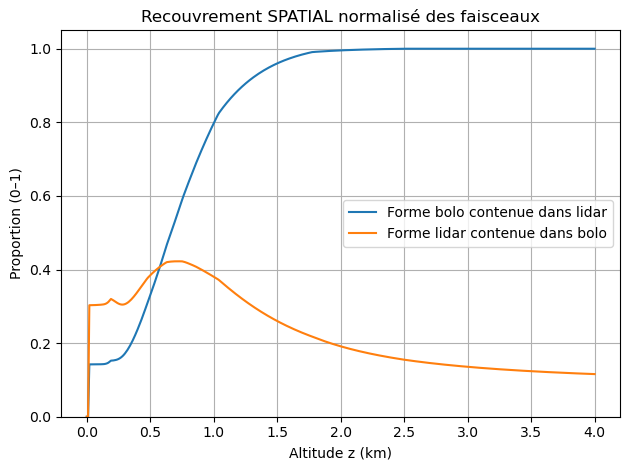

In [27]:
# -----------------------------------------------------------
# Recouvrement SPATIAL normalisé (pas de tau)
# -----------------------------------------------------------

dx = x[1] - x[0]
dy = y[1] - y[0]

P_B_in_L = []  # fraction de forme bolo contenue dans lidar
P_L_in_B = []  # fraction de forme lidar contenue dans bolo

for iz in range(len(z)):
    IB_plane = I_B[:, :, iz]
    IL_plane = I_L[:, :, iz]

    # si le plan est vide pour l'un des deux, on met 0
    if IB_plane.max() <= 0 or IL_plane.max() <= 0:
        P_B_in_L.append(0.0)
        P_L_in_B.append(0.0)
        continue

    # Normalisation de forme (max = 1)
    b = IB_plane / IB_plane.max()
    l = IL_plane / IL_plane.max()

    # intégrales (≈ sommes * dx * dy)
    S_B   = np.sum(b) * dx * dy
    S_L   = np.sum(l) * dx * dy
    S_min = np.sum(np.minimum(b, l)) * dx * dy

    P_B_in_L.append(S_min / S_B)
    P_L_in_B.append(S_min / S_L)

P_B_in_L = np.array(P_B_in_L)
P_L_in_B = np.array(P_L_in_B)

# -----------------------------------------------------------
# Plot des recouvrements spatiaux normalisés
# -----------------------------------------------------------

plt.figure()
plt.plot(z/1000.0, P_B_in_L, label="Forme bolo contenue dans lidar")
plt.plot(z/1000.0, P_L_in_B, label="Forme lidar contenue dans bolo")
plt.xlabel("Altitude z (km)")
plt.ylabel("Proportion (0–1)")
plt.title("Recouvrement SPATIAL normalisé des faisceaux")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
